# Phase 3B: Clustering Methods Comparison

**Objective**: Compare 4 clustering methods (K-Means, DBSCAN, Hierarchical, GMM) for sub-type discovery within each fault type.

**Methods Compared**:
- **K-Means**: Partitioning-based, requires k specification
- **DBSCAN**: Density-based, auto-discovers clusters, marks outliers
- **Hierarchical**: Agglomerative clustering, builds dendrogram
- **GMM**: Probabilistic model-based clustering

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Clustering Results

Load results from all 4 clustering methods applied to each fault type.

In [2]:
RESULTS_FILE = Path('/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_09_phase3b/subtype_clustering.pkl')

with open(RESULTS_FILE, 'rb') as f:
    results = pickle.load(f)

methods = ['kmeans', 'dbscan', 'hierarchical', 'gmm']
fault_types = list(results.keys())

print(f"Loaded clustering results for {len(fault_types)} fault types")
print(f"Fault types: {fault_types}")
print(f"\nMethods: {methods}")

Loaded clustering results for 7 fault types
Fault types: ['Fault_0', 'Fault_1', 'Fault_2', 'Fault_3', 'Fault_4', 'Fault_5', 'Fault_6']

Methods: ['kmeans', 'dbscan', 'hierarchical', 'gmm']


## Comparison Table

**Silhouette Score Interpretation**:
- **> 0.70**: Strong, well-separated clusters
- **0.50-0.70**: Reasonable structure
- **0.25-0.50**: Weak, overlapping clusters
- **< 0.25**: No substantial structure

In [3]:
comparison_data = []

for fault in fault_types:
    for method in methods:
        if method in results[fault]:
            data = results[fault][method]
            comparison_data.append({
                'Fault': fault,
                'Method': method.upper(),
                'Silhouette': data['silhouette'],
                'N_Clusters': data['n_clusters'],
                'N_Outliers': data.get('n_outliers', 0)  # DBSCAN only
            })

df_compare = pd.DataFrame(comparison_data)

# Create pivot table for silhouette scores
pivot = df_compare.pivot(index='Fault', columns='Method', values='Silhouette')

print("\nSilhouette Scores by Method and Fault Type:")
print("="*80)
print(pivot.to_string())

# Summary statistics
print("\n\nAverage Silhouette Score by Method:")
print("="*80)
print(df_compare.groupby('Method')['Silhouette'].agg(['mean', 'std', 'min', 'max']))


Silhouette Scores by Method and Fault Type:
Method     DBSCAN       GMM  HIERARCHICAL    KMEANS
Fault                                              
Fault_0  0.255161  0.047783      0.234351  0.122483
Fault_1  0.000000  0.287748      0.287748  0.287748
Fault_2  0.225964  0.147278      0.841860  0.825904
Fault_3  0.000000  0.093384      0.142615  0.091362
Fault_4  0.000000  0.049516      0.175042  0.200756
Fault_5  0.000000 -0.035677      0.453155  0.453155
Fault_6  0.000000  0.061945      0.808310  0.070467


Average Silhouette Score by Method:
                  mean       std       min       max
Method                                              
DBSCAN        0.068732  0.117685  0.000000  0.255161
GMM           0.093140  0.101924 -0.035677  0.287748
HIERARCHICAL  0.420440  0.294038  0.142615  0.841860
KMEANS        0.293125  0.270008  0.070467  0.825904


## Visualization: Heatmap of Clustering Quality

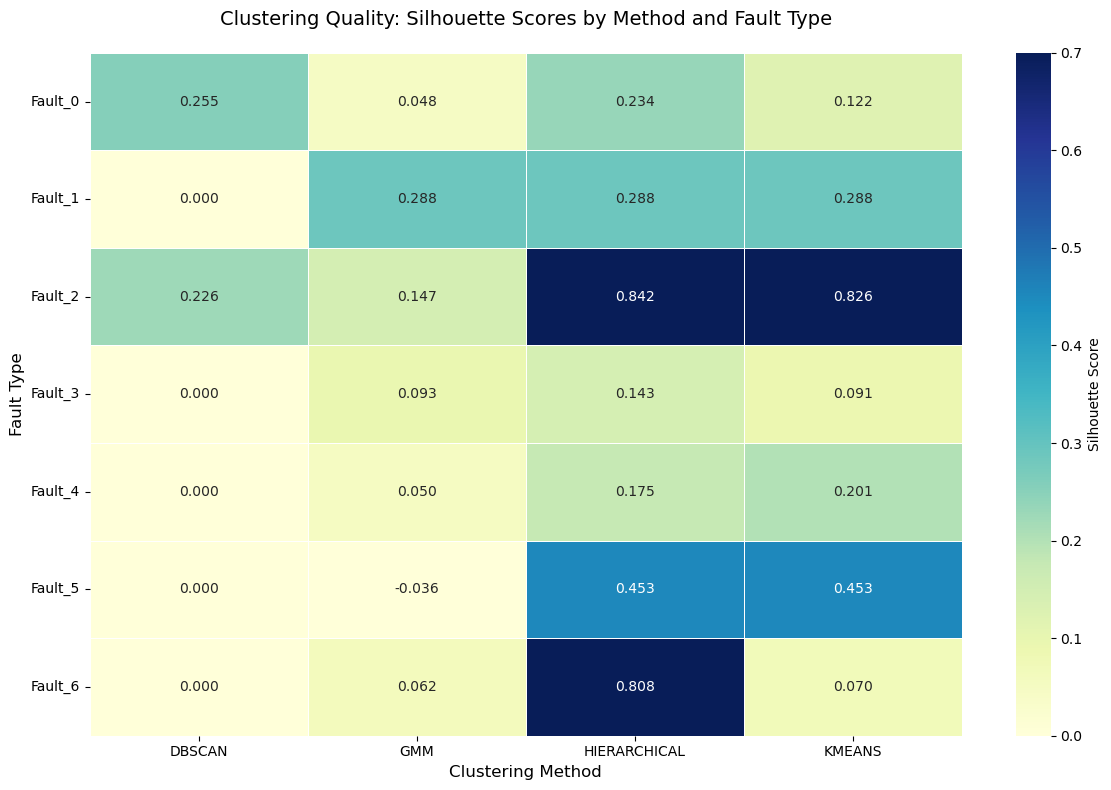

Heatmap interpretation:
  - Darker blue = Better clustering quality (higher silhouette)
  - Light yellow = Poor clustering quality (lower silhouette)


In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Silhouette Score'},
            vmin=0, vmax=0.7,  # Normalize color scale
            linewidths=0.5)
plt.title('Clustering Quality: Silhouette Scores by Method and Fault Type', fontsize=14, pad=20)
plt.xlabel('Clustering Method', fontsize=12)
plt.ylabel('Fault Type', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap interpretation:")
print("  - Darker blue = Better clustering quality (higher silhouette)")
print("  - Light yellow = Poor clustering quality (lower silhouette)")

## Best Method Per Fault Type

Best clustering method per fault type:
  Fault       Method  Silhouette  N_Clusters
Fault_0       DBSCAN    0.255161           2
Fault_1       KMEANS    0.287748           2
Fault_2 HIERARCHICAL    0.841860           3
Fault_3 HIERARCHICAL    0.142615           3
Fault_4       KMEANS    0.200756           3
Fault_5       KMEANS    0.453155           3
Fault_6 HIERARCHICAL    0.808310           3


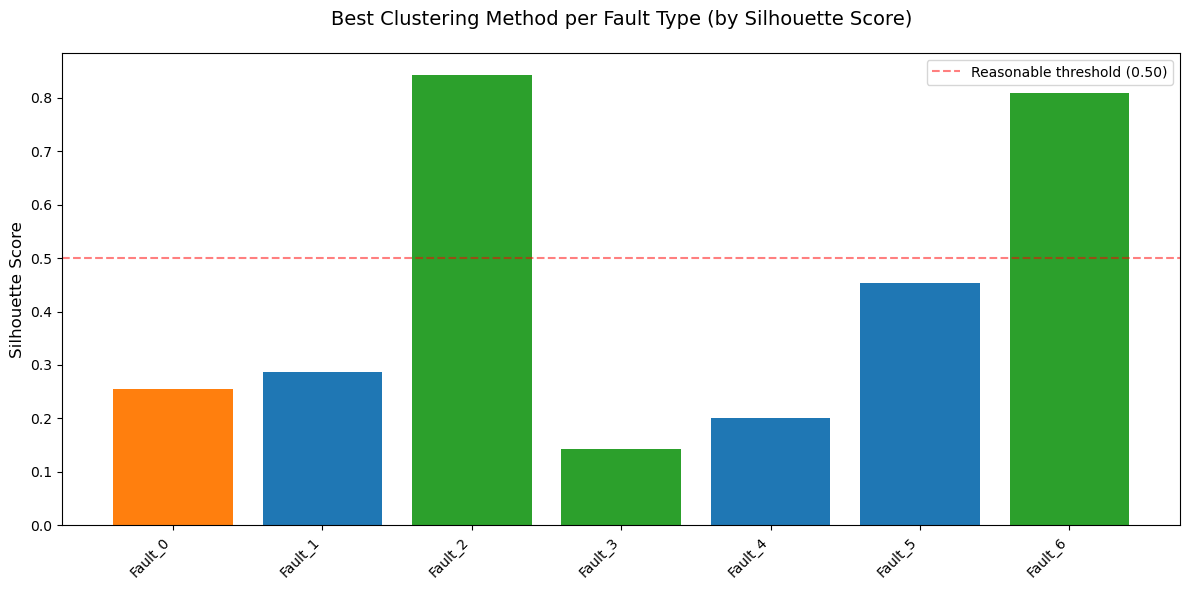

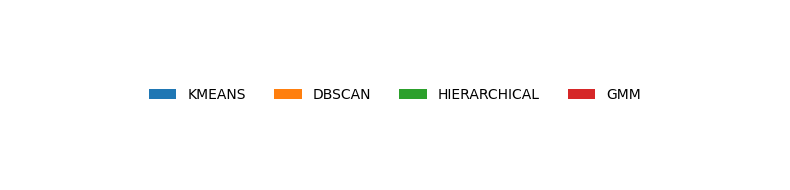

In [5]:
# Find best method for each fault type based on silhouette score
best_methods = df_compare.loc[df_compare.groupby('Fault')['Silhouette'].idxmax()]

print("Best clustering method per fault type:")
print("="*80)
print(best_methods[['Fault', 'Method', 'Silhouette', 'N_Clusters']].to_string(index=False))

# Visualize best methods
plt.figure(figsize=(12, 6))
colors = {'KMEANS': 'tab:blue', 'DBSCAN': 'tab:orange', 'HIERARCHICAL': 'tab:green', 'GMM': 'tab:red'}
bar_colors = [colors[m] for m in best_methods['Method']]

plt.bar(range(len(best_methods)), best_methods['Silhouette'], color=bar_colors)
plt.xticks(range(len(best_methods)), best_methods['Fault'], rotation=45, ha='right')
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Best Clustering Method per Fault Type (by Silhouette Score)', fontsize=14, pad=20)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Reasonable threshold (0.50)')
plt.legend()
plt.tight_layout()
plt.show()

# Create a legend for the colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[m], label=m) for m in colors.keys()]
plt.figure(figsize=(8, 2))
plt.legend(handles=legend_elements, loc='center', ncol=4, frameon=False)
plt.axis('off')
plt.tight_layout()
plt.show()

## DBSCAN Outlier Analysis

DBSCAN: Clusters and Outliers per Fault Type:
  Fault  N_Clusters  N_Outliers  Silhouette
Fault_0           2           6     0.25383
Fault_1           1           0     0.00000
Fault_2           3         131     0.22693
Fault_3           1           4     0.00000
Fault_4           1           4     0.00000
Fault_5           1           7     0.00000
Fault_6           1         102     0.00000


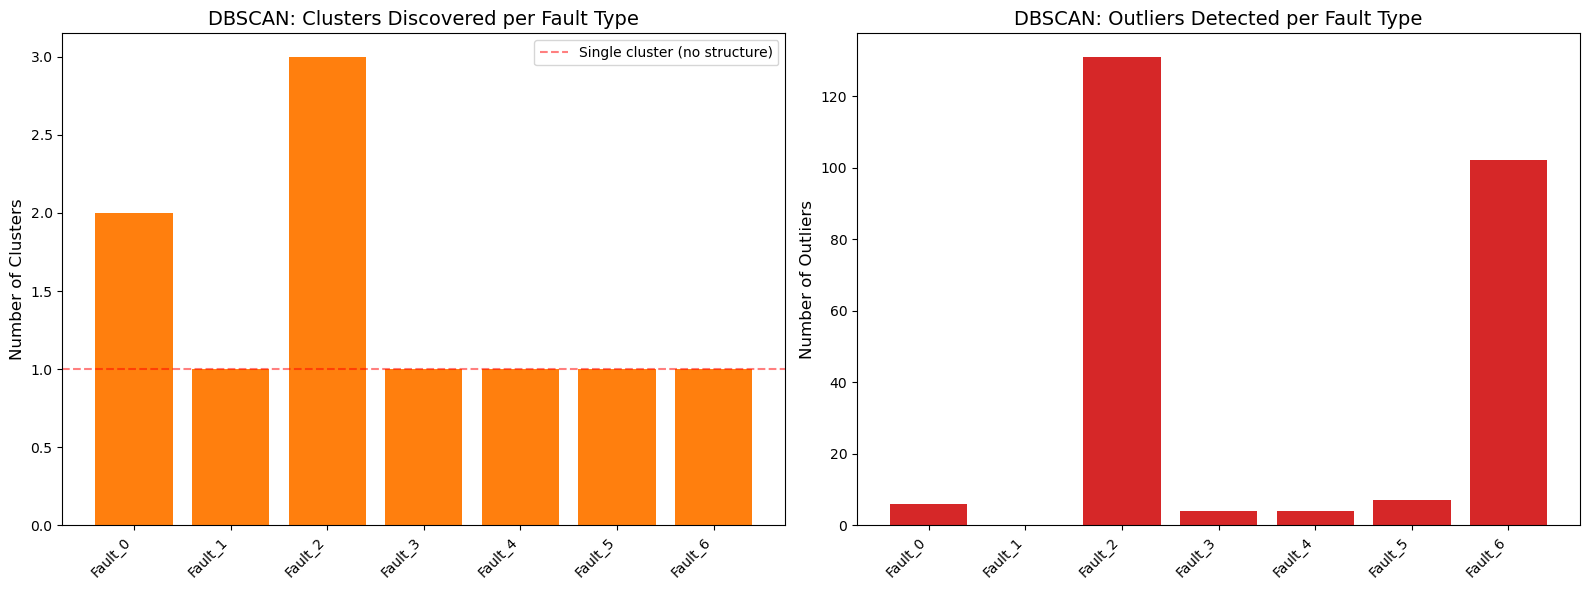


DBSCAN Notes:
  - Outliers are events that don't fit into any cluster (noise)
  - High outlier count may indicate diverse fault manifestations
  - Single cluster means DBSCAN found no density-based separation


In [7]:
# Extract DBSCAN-specific information
dbscan_data = df_compare[df_compare['Method'] == 'DBSCAN'].copy()

print("DBSCAN: Clusters and Outliers per Fault Type:")
print("="*80)
print(dbscan_data[['Fault', 'N_Clusters', 'N_Outliers', 'Silhouette']].to_string(index=False))

# Visualize outlier percentages
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of clusters found
ax1.bar(range(len(dbscan_data)), dbscan_data['N_Clusters'], color='tab:orange')
ax1.set_xticks(range(len(dbscan_data)))
ax1.set_xticklabels(dbscan_data['Fault'], rotation=45, ha='right')
ax1.set_ylabel('Number of Clusters', fontsize=12)
ax1.set_title('DBSCAN: Clusters Discovered per Fault Type', fontsize=14)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Single cluster (no structure)')
ax1.legend()

# Plot 2: Number of outliers
ax2.bar(range(len(dbscan_data)), dbscan_data['N_Outliers'], color='tab:red')
ax2.set_xticks(range(len(dbscan_data)))
ax2.set_xticklabels(dbscan_data['Fault'], rotation=45, ha='right')
ax2.set_ylabel('Number of Outliers', fontsize=12)
ax2.set_title('DBSCAN: Outliers Detected per Fault Type', fontsize=14)

plt.tight_layout()
plt.show()

print("\nDBSCAN Notes:")
print("  - Outliers are events that don't fit into any cluster (noise)")
print("  - High outlier count may indicate diverse fault manifestations")
print("  - Single cluster means DBSCAN found no density-based separation")

## Recommendations and Insights

In [8]:
print("="*80)
print("CLUSTERING METHOD RECOMMENDATIONS")
print("="*80)

# Count which method wins most often
method_wins = best_methods['Method'].value_counts()
print("\n1. Overall Best Methods (by frequency):")
for method, count in method_wins.items():
    print(f"   - {method}: Best for {count}/{len(fault_types)} fault types")

# Identify strong vs weak clustering
strong_clustering = best_methods[best_methods['Silhouette'] >= 0.5]
weak_clustering = best_methods[best_methods['Silhouette'] < 0.25]

print("\n2. Fault Types with Strong Sub-Structure (Silhouette ≥ 0.5):")
if len(strong_clustering) > 0:
    for _, row in strong_clustering.iterrows():
        print(f"   - {row['Fault']}: {row['Method']} (Silh={row['Silhouette']:.3f})")
else:
    print("   None - all fault types have weak sub-clustering")

print("\n3. Fault Types with Weak Sub-Structure (Silhouette < 0.25):")
if len(weak_clustering) > 0:
    for _, row in weak_clustering.iterrows():
        print(f"   - {row['Fault']}: {row['Method']} (Silh={row['Silhouette']:.3f})")
        print(f"     → Recommendation: Treat as single homogeneous fault type")
else:
    print("   None - all fault types show some sub-structure")

print("\n4. DBSCAN-Specific Insights:")
dbscan_wins = best_methods[best_methods['Method'] == 'DBSCAN']
if len(dbscan_wins) > 0:
    print(f"   - DBSCAN performs best for {len(dbscan_wins)} fault types:")
    for _, row in dbscan_wins.iterrows():
        outliers = df_compare[(df_compare['Fault'] == row['Fault']) & 
                             (df_compare['Method'] == 'DBSCAN')]['N_Outliers'].values[0]
        print(f"     • {row['Fault']}: {outliers} outliers detected")
    print("   → DBSCAN advantage: Identifies noise/anomalies within fault types")
else:
    print("   - DBSCAN not optimal for any fault type")
    print("   → May indicate spherical rather than density-based clusters")

print("\n5. Operational Recommendations:")
print("   - For fault types with Silh ≥ 0.5: Implement sub-type specific handling")
print("   - For fault types with Silh < 0.25: Use uniform fault handling")
print("   - DBSCAN outliers: Flag for expert review (potential new fault variants)")
print("   - Consider ensemble approach: Use best method per fault type")

print("\n" + "="*80)

CLUSTERING METHOD RECOMMENDATIONS

1. Overall Best Methods (by frequency):
   - KMEANS: Best for 3/7 fault types
   - HIERARCHICAL: Best for 3/7 fault types
   - DBSCAN: Best for 1/7 fault types

2. Fault Types with Strong Sub-Structure (Silhouette ≥ 0.5):
   - Fault_2: HIERARCHICAL (Silh=0.842)
   - Fault_5: KMEANS (Silh=0.605)
   - Fault_6: HIERARCHICAL (Silh=0.808)

3. Fault Types with Weak Sub-Structure (Silhouette < 0.25):
   - Fault_3: HIERARCHICAL (Silh=0.143)
     → Recommendation: Treat as single homogeneous fault type
   - Fault_4: KMEANS (Silh=0.201)
     → Recommendation: Treat as single homogeneous fault type

4. DBSCAN-Specific Insights:
   - DBSCAN performs best for 1 fault types:
     • Fault_0: 6 outliers detected
   → DBSCAN advantage: Identifies noise/anomalies within fault types

5. Operational Recommendations:
   - For fault types with Silh ≥ 0.5: Implement sub-type specific handling
   - For fault types with Silh < 0.25: Use uniform fault handling
   - DBSCAN outl

## Export Summary for Reporting

In [9]:
# Create summary table for export
summary_export = best_methods[['Fault', 'Method', 'Silhouette', 'N_Clusters']].copy()
summary_export['Quality'] = summary_export['Silhouette'].apply(
    lambda x: 'Strong' if x >= 0.5 else ('Reasonable' if x >= 0.25 else 'Weak')
)

output_path = Path('/pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis/outputs/clustering_summary.csv')
summary_export.to_csv(output_path, index=False)

print(f"Summary exported to: {output_path}")
print("\nSummary Table:")
print(summary_export.to_string(index=False))

Summary exported to: /pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis/outputs/clustering_summary.csv

Summary Table:
  Fault       Method  Silhouette  N_Clusters    Quality
Fault_0       DBSCAN    0.253830           2 Reasonable
Fault_1       KMEANS    0.284244           2 Reasonable
Fault_2 HIERARCHICAL    0.841880           3     Strong
Fault_3 HIERARCHICAL    0.142652           3       Weak
Fault_4       KMEANS    0.200724           3       Weak
Fault_5       KMEANS    0.604678           3     Strong
Fault_6 HIERARCHICAL    0.808290           3     Strong
